In [16]:
import pandas as pd
import numpy as np

In [17]:
df = pd.read_csv("food_wastage_cleaned.csv")

In [18]:
df.head()

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
0,meat,310.0,corporate,450.0,refrigerated,Regular,All Seasons,Buffet,Urban,Low,25.0
1,meat,400.0,birthday,500.0,room temperature,Regular,Winter,Buffet,Suburban,High,40.0
2,vegetables,302.0,birthday,400.0,refrigerated,Regular,Summer,Buffet,Suburban,Low,27.0
3,meat,491.0,birthday,497.0,refrigerated,Regular,All Seasons,Finger Food,Rural,High,32.0
4,meat,300.0,corporate,400.0,refrigerated,Regular,Winter,Finger Food,Urban,Moderate,25.0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1723 entries, 0 to 1722
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Type of Food           1723 non-null   object 
 1   Number of Guests       1723 non-null   float64
 2   Event Type             1723 non-null   object 
 3   Quantity of Food       1723 non-null   float64
 4   Storage Conditions     1723 non-null   object 
 5   Purchase History       1723 non-null   object 
 6   Seasonality            1723 non-null   object 
 7   Preparation Method     1723 non-null   object 
 8   Geographical Location  1723 non-null   object 
 9   Pricing                1723 non-null   object 
 10  Wastage Food Amount    1723 non-null   float64
dtypes: float64(3), object(8)
memory usage: 148.2+ KB


## Encoding

In [20]:
from sklearn.preprocessing import LabelEncoder

In [21]:
le = LabelEncoder()

In [22]:
categorical_columns = [
    'Type of Food',
    'Event Type',
    'Storage Conditions',
    'Purchase History',
    'Seasonality',
    'Preparation Method',
    'Geographical Location',
    'Pricing'
]

In [23]:
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
0,3,310.0,1,450.0,0,1,0,0,2,1,25.0
1,3,400.0,0,500.0,1,1,2,0,1,0,40.0
2,4,302.0,0,400.0,0,1,1,0,1,1,27.0
3,3,491.0,0,497.0,0,1,0,1,0,0,32.0
4,3,300.0,1,400.0,0,1,2,1,2,2,25.0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1723 entries, 0 to 1722
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Type of Food           1723 non-null   int64  
 1   Number of Guests       1723 non-null   float64
 2   Event Type             1723 non-null   int64  
 3   Quantity of Food       1723 non-null   float64
 4   Storage Conditions     1723 non-null   int64  
 5   Purchase History       1723 non-null   int64  
 6   Seasonality            1723 non-null   int64  
 7   Preparation Method     1723 non-null   int64  
 8   Geographical Location  1723 non-null   int64  
 9   Pricing                1723 non-null   int64  
 10  Wastage Food Amount    1723 non-null   float64
dtypes: float64(3), int64(8)
memory usage: 148.2 KB


## save the encoding mapping for streamlit later on.

In [25]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd # Ensure pandas is imported for pd.read_csv

categorical_columns = [
    'Type of Food',
    'Event Type',
    'Storage Conditions',
    'Purchase History',
    'Seasonality',
    'Preparation Method',
    'Geographical Location',
    'Pricing'
]

encoders = {}

# Load a fresh, unencoded copy of the DataFrame to fit the LabelEncoders.
# This ensures that the encoders are fitted on the original string values
# without altering the 'df' that has already been transformed for model training.
df_raw = pd.read_csv("food_wastage_cleaned.csv")

for col in categorical_columns:
    le = LabelEncoder()
    # Fit the encoder using the raw (string) categorical data
    le.fit(df_raw[col])
    # Store the fitted encoder in the dictionary
    encoders[col] = le

# Note: The main 'df' used for the model is already encoded by cell 77a53454-976e-4aff-861b-de82bb0acdc8.
# This cell only serves to create and store the LabelEncoder objects for later use (e.g., Streamlit).
# Therefore, we do not perform df[col] = le.fit_transform(df_raw[col]) here to avoid re-encoding or overwriting the main df.

In [26]:
for col in categorical_columns:
    print(f"\n{col}")
    print(dict(zip(
        encoders[col].classes_,
        encoders[col].transform(encoders[col].classes_)
    )))


Type of Food
{'baked goods': np.int64(0), 'dairy products': np.int64(1), 'fruits': np.int64(2), 'meat': np.int64(3), 'vegetables': np.int64(4)}

Event Type
{'birthday': np.int64(0), 'corporate': np.int64(1), 'social gathering': np.int64(2), 'wedding': np.int64(3)}

Storage Conditions
{'refrigerated': np.int64(0), 'room temperature': np.int64(1)}

Purchase History
{'Occasional': np.int64(0), 'Regular': np.int64(1)}

Seasonality
{'All Seasons': np.int64(0), 'Summer': np.int64(1), 'Winter': np.int64(2)}

Preparation Method
{'Buffet': np.int64(0), 'Finger Food': np.int64(1), 'Sit-down Dinner': np.int64(2)}

Geographical Location
{'Rural': np.int64(0), 'Suburban': np.int64(1), 'Urban': np.int64(2)}

Pricing
{'High': np.int64(0), 'Low': np.int64(1), 'Moderate': np.int64(2)}


## Define Features & Target

In [27]:
X = df.drop('Wastage Food Amount', axis=1)

In [28]:
y = df['Wastage Food Amount']

In [29]:
print(X.shape)
print(y.shape)

(1723, 10)
(1723,)


## Scaling

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler()

In [32]:
X_scaled = scaler.fit_transform(X)

In [33]:
X_scaled

array([[ 0.88069135, -0.16729727, -0.50757832, ..., -1.74954535,
         1.25289056,  0.01341626],
       [ 0.88069135,  0.96498224, -1.43598325, ..., -1.74954535,
        -0.12472937, -1.14239485],
       [ 1.61910069, -0.26794434, -1.43598325, ..., -1.74954535,
        -0.12472937,  0.01341626],
       ...,
       [ 0.88069135, -0.16729727,  1.34923155, ...,  0.99337243,
        -0.12472937,  0.01341626],
       [-1.33453668,  5.55700473, -0.50757832, ...,  0.99337243,
        -0.12472937,  0.01341626],
       [-0.59612733, -0.16729727, -0.50757832, ...,  0.99337243,
        -0.12472937,  0.01341626]])

## Train Test Split

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
print(X_train.shape)
print(X_test.shape)

(1378, 10)
(345, 10)


## Train First Model (Linear Regression)

In [37]:
from sklearn.linear_model import LinearRegression

In [38]:
lr_model = LinearRegression()

In [39]:
# Train Model
lr_model.fit(X_train, y_train)

LinearRegression()

In [40]:
# Prediction
y_pred_lr = lr_model.predict(X_test)
y_pred_lr

array([21.8418618 , 29.11747797, 21.59070458, 20.01985613, 32.11155765,
       32.60475132, 26.09504024, 24.89867301, 37.41974819, 20.06481151,
       17.96644338, 17.91218702, 21.96210202, 23.60780933, 26.67692314,
       34.86671142, 16.61133035, 40.38363643, 40.84171723, 31.82879687,
       40.13614677, 17.77769084, 19.71726572, 28.32650609, 33.59673543,
       21.18785539, 32.72484142, 24.76967924, 19.25837946, 25.48231988,
       33.74831048, 38.05319705, 27.7089461 , 26.1943879 , 16.3137737 ,
       16.34661038, 24.2272344 , 27.85587319, 22.52716816, 33.70525665,
       36.75568153, 44.29097686, 23.13399165, 19.92112029, 39.10584179,
       24.47459708, 34.03506311, 33.40544727, 34.2685285 , 34.51180761,
       24.3299537 , 18.2861549 , 25.73447701, 35.67265101, 34.94584488,
       18.44593854, 23.32808615, 24.07806891, 33.25833712, 25.69667169,
       23.8028917 , 22.28897197, 20.16625082, 25.12297496, 31.61420038,
       30.94785747, 37.17929086, 27.64348534, 30.75364924, 36.83

## Evaluate Model

In [41]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [42]:
# check performance
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 5.581155004070281
MSE: 50.215660416932785
RMSE: 7.086300897995567
R2 Score: 0.4899620072331805


In [43]:
# saving results
results = pd.DataFrame({
    'Model': ['Linear Regression'],
    'MAE': [mae],
    'MSE': [mse],
    'RMSE': [rmse],
    'R2 Score': [r2]
})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,5.581155,50.21566,7.086301,0.489962


## Model 2 — Decision Tree Regressor

In [44]:
from sklearn.tree import DecisionTreeRegressor

In [45]:
dt_model = DecisionTreeRegressor(random_state=42)

In [46]:
# Train model
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [47]:
# Prediction
y_pred_dt = dt_model.predict(X_test)

In [48]:
# Evaluate Model
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("MAE:", mae_dt)
print("MSE:", mse_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

MAE: 2.734782608695652
MSE: 28.509420289855072
RMSE: 5.339421344102287
R2 Score: 0.7104312204827617


In [49]:
new_result = pd.DataFrame({
    'Model': ['Decision Tree'],
    'MAE': [mae_dt],
    'MSE': [mse_dt],
    'RMSE': [rmse_dt],
    'R2 Score': [r2_dt]
})

results = pd.concat([results, new_result], ignore_index=True)

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,5.581155,50.21566,7.086301,0.489962
1,Decision Tree,2.734783,28.50942,5.339421,0.710431


## Model 3 — Random Forest Regressor ⭐

In [50]:
from sklearn.ensemble import RandomForestRegressor

In [51]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [52]:
# Train
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [53]:
# Prediction
y_pred_rf = rf_model.predict(X_test)

In [54]:
# Evaluate Model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE: 2.3988045883263274
MSE: 15.68172418716524
RMSE: 3.9600156801665873
R2 Score: 0.8407214988086144


In [55]:
new_result = pd.DataFrame({
    'Model': ['Random Forest'],
    'MAE': [mae_rf],
    'MSE': [mse_rf],
    'RMSE': [rmse_rf],
    'R2 Score': [r2_rf]
})

results = pd.concat([results, new_result], ignore_index=True)

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,5.581155,50.215660,7.086301,0.489962
1,Decision Tree,2.734783,28.509420,5.339421,0.710431
2,Random Forest,2.398805,15.681724,3.960016,0.840721


## Compare Models Properly

In [56]:
results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,5.581155,50.215660,7.086301,0.489962
1,Decision Tree,2.734783,28.509420,5.339421,0.710431
2,Random Forest,2.398805,15.681724,3.960016,0.840721


In [57]:
results.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,MAE,MSE,RMSE,R2 Score
2,Random Forest,2.398805,15.681724,3.960016,0.840721
1,Decision Tree,2.734783,28.509420,5.339421,0.710431
0,Linear Regression,5.581155,50.215660,7.086301,0.489962


## Visualization of Model Comparison ⭐

In [58]:
import matplotlib.pyplot as plt

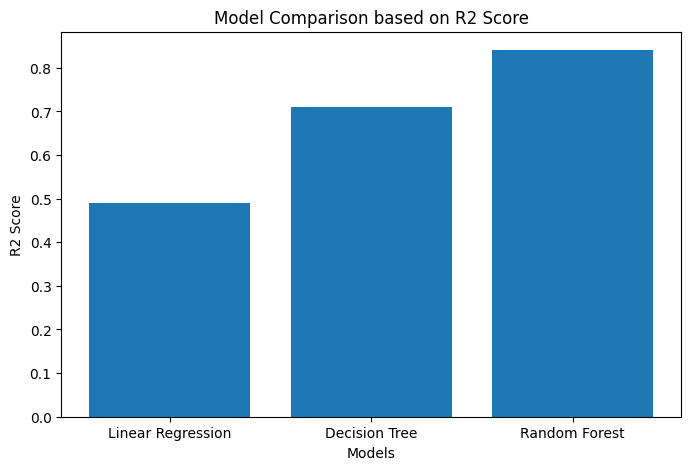

In [59]:
# R² Score Comparison
plt.figure(figsize=(8,5))

plt.bar(results['Model'], results['R2 Score'])

plt.title("Model Comparison based on R2 Score")
plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.show()

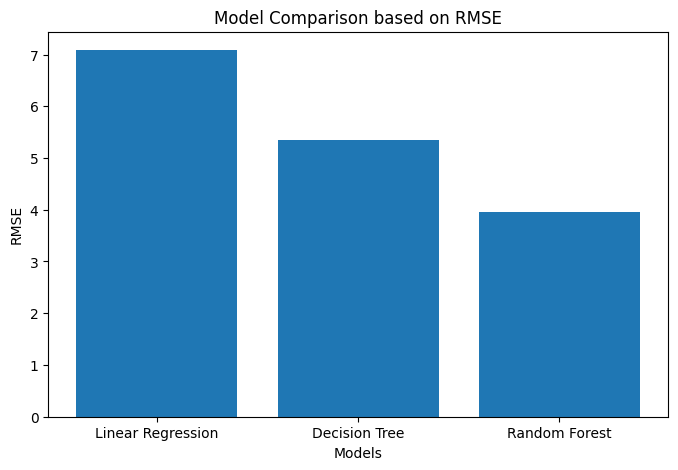

In [60]:
# RMSE comparison
plt.figure(figsize=(8,5))

plt.bar(results['Model'], results['RMSE'])

plt.title("Model Comparison based on RMSE")
plt.xlabel("Models")
plt.ylabel("RMSE")

plt.show()

## Test One Prediction

In [61]:
sample_input = pd.DataFrame([{
    'Type of Food': 3,
    'Number of Guests': 380,
    'Event Type': 0,
    'Quantity of Food': 500,
    'Storage Conditions': 0,
    'Purchase History': 1,
    'Seasonality': 2,
    'Preparation Method': 2,
    'Geographical Location': 1,
    'Pricing': 0
}])

In [62]:
sample_input_scaled = scaler.transform(sample_input)

In [63]:
prediction = rf_model.predict(sample_input_scaled)

print("Predicted Food Wastage:", prediction[0])

Predicted Food Wastage: 35.25


## Feature Importance

In [64]:
prediction = rf_model.predict(sample_input_scaled)

print("Predicted Food Wastage:", prediction[0])

Predicted Food Wastage: 35.25


In [65]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance

,Feature,Importance
0,Type of Food,0.027266
1,Number of Guests,0.174221
2,Event Type,0.023186
3,Quantity of Food,0.102179
4,Storage Conditions,0.008507
5,Purchase History,0.005364
6,Seasonality,0.017370
7,Preparation Method,0.047117
8,Geographical Location,0.018994
9,Pricing,0.575795


In [66]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
9,Pricing,0.575795
1,Number of Guests,0.174221
3,Quantity of Food,0.102179
7,Preparation Method,0.047117
0,Type of Food,0.027266
2,Event Type,0.023186
8,Geographical Location,0.018994
6,Seasonality,0.017370
4,Storage Conditions,0.008507
5,Purchase History,0.005364


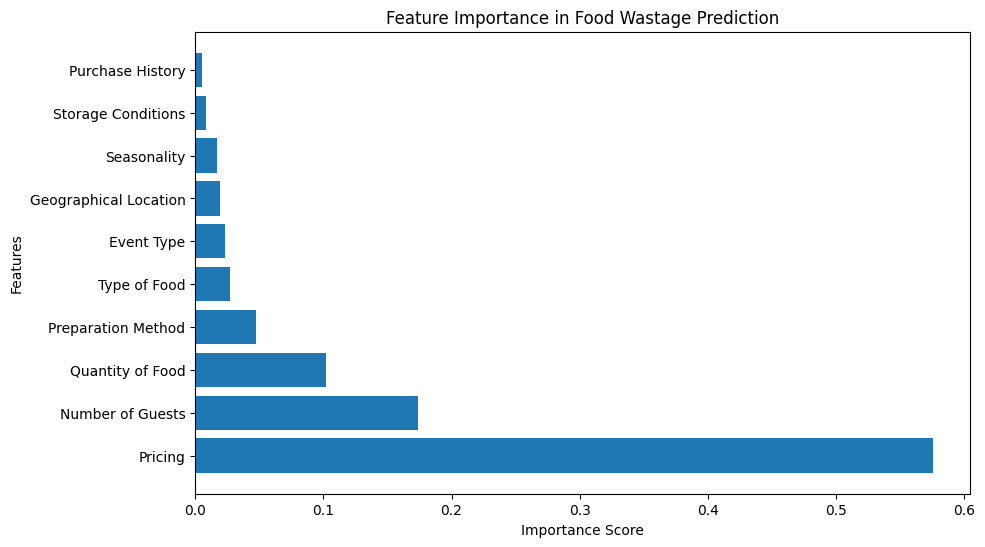

In [67]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title("Feature Importance in Food Wastage Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

## Save Best Model ⭐

In [68]:
import joblib

In [69]:
# save model
joblib.dump(rf_model, 'food_wastage_model.pkl')

['food_wastage_model.pkl']

In [70]:
# save scalar
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [71]:
# save Encoders
joblib.dump(encoders, 'encoders.pkl')

['encoders.pkl']